
# ACECQA Education & Care Services — Full Analysis (Quality, Accessibility, Operations)

**Business context:** I work for government to improve education and care services across Australia. This notebook analyses the national register of approved education and care services (17,663 rows, NQA ITS extract) enriched with spatial/transport-access fields, across three streams:

**1. Service Quality** — how NQS ratings vary by state and service type, which Quality Area drags scores down, and whether transport proximity predicts quality.

**2. Accessibility & Coverage** — four charts, each answering one of the assignment's four requirements directly: the geographic concentration of services, the specific regions where new services are most needed, how well services are connected to public transport, and where the transport-underserved services actually are.

**3. Operational Trends** — capacity and opening-hours patterns by service type, sector growth over time, and whether operational factors (or transport access) relate to quality.

Run the cells top to bottom. In Colab, the first code cell clones the source repo (raw data, a basemap file, and the ABS boundary shapefile used for the urban/rural classification) and installs dependencies.

**Design note:** every chart's headline stats are written into a running `summary` dict *immediately* after that chart is drawn, not recomputed later from leftover variables — this avoids a class of bug where a later cell's reused variable name (e.g. `worst`) silently overwrites an earlier cell's value before the final summary is written.


In [1]:

# --- Setup: run this first in Google Colab ---
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not os.path.exists("Mart"):
    !git clone -b claude/acecqa-services-analysis-olfr4o https://github.com/martvanhoorn2003-svg/Mart.git
    %cd Mart
    !pip install -q geopandas scipy pyarrow

if os.path.basename(os.getcwd()) != "Mart" and os.path.isdir("Mart"):
    os.chdir("Mart")

print("Working directory:", os.getcwd())
print("Data file present:", os.path.exists("data/education_services.csv"))
print("SOS shapefile present:", os.path.exists("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp"))


Working directory: /home/user/Mart
Data file present: True
SOS shapefile present: True


In [2]:

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.spatial import cKDTree
import geopandas as gpd

RAW_PATH = Path("data/education_services.csv")
AU_STATES_GEOJSON = Path("data/external/au_states.geojson")
SOS_SHAPEFILE = Path("data/external/sos_2021/SOS_2021_AUST_GDA2020.shp")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
summary = {}  # every chart appends its own headline stats here, right after drawing



## 1. Load the raw data and look for problems before trusting it

Before any analysis, check what's actually in the file — missing values, duplicate/implausible coordinates, and category values that don't match what the data dictionary implies.


In [3]:

raw = pd.read_csv(RAW_PATH, low_memory=False)
print(raw.shape)
raw[["ServiceName", "State", "Suburb", "Postcode", "geometry"]].head()


(17663, 103)


,ServiceName,State,Suburb,Postcode,geometry
0,Community Kids Waterford Early Education Centre,QLD,WATERFORD WEST,4133.0,"c(153.133902919075, -27.690513207433)"
1,KIDVENTURE EARLY LEARNING EAGLEBY,QLD,EAGLEBY,4207.0,"c(153.211787647201, -27.707467576353)"
2,Community Kids - Broadbeach Waters,QLD,BROADBEACH WATERS,4217.0,"c(153.410339594544, -28.024767831911)"
3,Little Scholars School of Early Learning Burle...,QLD,BURLEIGH WATERS,4220.0,"c(153.431380518447, -28.082157591396)"
4,Small World Child Care Centre,QLD,CARRARA,4211.0,"c(153.351670127991, -28.005580607804)"


In [4]:

dup_geom = raw["geometry"].value_counts()
dup_geom = dup_geom[dup_geom > 3]
print(dup_geom)


geometry
c(97.48747, 23.14958)                    10
c(145.741929531156, -17.007042588225)     4
c(145.363114748785, -38.083890922407)     4
c(151.128664850783, -33.878545511457)     4
c(149.1025717692, -35.307236507212)       4
Name: count, dtype: int64



**Finding:** `c(97.48747, 23.14958)` is shared by 10 services — and that coordinate is in Myanmar, not Australia.


In [5]:

bad = raw[raw["geometry"] == "c(97.48747, 23.14958)"]
bad[["ServiceName", "State", "Suburb", "Postcode", "FullAddress"]]


,ServiceName,State,Suburb,Postcode,FullAddress
1590,Ace Academy Morayfield,NaN,NaN,NaN,"NA, NA, NA, NA"
5385,Callala Bay Preschool Education Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
6370,Koolyangarra Aboriginal Preschool Corporation,NaN,NaN,NaN,"NA, NA, NA, NA"
6731,Merriwa Pre-School And Activity Centre Incorpo...,NaN,NaN,NaN,"NA, NA, NA, NA"
7266,Guardian Childcare & Education Margaret Street,NaN,NaN,NaN,"NA, NA, NA, NA"
12140,Clarence City Council - Lindisfarne North OSHC,NaN,NaN,NaN,"NA, NA, NA, NA"
12909,Blossoms Childcare & Early Learning Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
12977,Genius Childcare Lane Cove,NaN,NaN,NaN,"NA, NA, NA, NA"
16713,Clarke Creek State School Kindergarten,NaN,NaN,NaN,"NA, NA, NA, NA"
16834,Grow Early Education Maroochydore,NaN,NaN,NaN,"NA, NA, NA, NA"



Every one of these 10 rows has **no State, Suburb, Postcode or address at all** — the location-enrichment step fell back to the same placeholder point when it had nothing to geocode. These rows are **dropped** rather than imputed: there's no address information to recover. (All other duplicate-coordinate cases were checked too — e.g. 4 services sharing one address in Ashfield, NSW — and are genuine co-located services, so those are kept.)

**`OverallRating`** also contains a value that isn't one of the five NQS tiers: `Provisional – Not Yet Assessed`. That's not a quality score — it means the service is newly approved and hasn't had its first assessment visit — so it's kept as its own explicit category rather than dropped or coded as missing.


In [6]:

NOT_YET_ASSESSED = "Provisional – Not Yet Assessed"
RATING_ORDER_SUBSTANTIVE = [
    "Significant Improvement Required", "Working Towards NQS", "Meeting NQS", "Exceeding NQS", "Excellent",
]
RATING_ORDER = [NOT_YET_ASSESSED] + RATING_ORDER_SUBSTANTIVE

QUALITY_AREA_LABELS = {
    "QualityArea1Rating": "QA1 Educational program",
    "QualityArea2Rating": "QA2 Children's health & safety",
    "QualityArea3Rating": "QA3 Physical environment",
    "QualityArea4Rating": "QA4 Staffing arrangements",
    "QualityArea5Rating": "QA5 Relationships with children",
    "QualityArea6Rating": "QA6 Collaborative partnerships",
    "QualityArea7Rating": "QA7 Governance & leadership",
}
RATING_COLS = ["OverallRating"] + list(QUALITY_AREA_LABELS.keys())

DETAILED_SERVICE_TYPE_COLS = [
    "Long Day Care", "Preschool/Kindergarten - Part of a School", "Preschool/Kindergarten - Stand alone",
    "Outside school Hours Care - After School", "Outside school Hours Care - Before School",
    "Outside school Hours Care - Vacation Care", "Other",
]

AU_LON_RANGE = (105.0, 170.0)
AU_LAT_RANGE = (-45.0, -8.0)
_GEOM_RE = re.compile(r"c\(\s*([-\d.]+)\s*,\s*([-\d.]+)\s*\)")


def parse_geometry(series):
    parsed = series.astype(str).str.extract(_GEOM_RE)
    lon = pd.to_numeric(parsed[0], errors="coerce")
    lat = pd.to_numeric(parsed[1], errors="coerce")
    return lon, lat


def clean(df):
    df = df.copy()
    n_start = len(df)

    bad_geocode = df["geometry"].eq("c(97.48747, 23.14958)")
    df = df.loc[~bad_geocode].copy()

    df["lon"], df["lat"] = parse_geometry(df["geometry"])
    out_of_bounds = (
        df["lon"].lt(AU_LON_RANGE[0]) | df["lon"].gt(AU_LON_RANGE[1]) |
        df["lat"].lt(AU_LAT_RANGE[0]) | df["lat"].gt(AU_LAT_RANGE[1])
    )
    df["geocode_suspect"] = out_of_bounds.fillna(True)

    df["ServiceApprovalGrantedDate"] = pd.to_datetime(df["ServiceApprovalGrantedDate"], dayfirst=True, errors="coerce")
    df["ApprovalYear"] = df["ServiceApprovalGrantedDate"].dt.year

    for col in RATING_COLS:
        df[col] = pd.Categorical(df[col], categories=RATING_ORDER, ordered=True)
    df["IsRated"] = df["OverallRating"].notna()

    for col in DETAILED_SERVICE_TYPE_COLS:
        df[col] = df[col].map({"Yes": True, "No": False})

    df["NumberOfApprovedPlaces"] = pd.to_numeric(df["NumberOfApprovedPlaces"], errors="coerce")

    df["train_dist_outlier"] = df["DistanceToTrainStation_km"] > 100
    df["bus_dist_outlier"] = df["DistanceToBusStation_km"] > 100

    df["State"] = df["State"].str.strip()
    df["Postcode"] = pd.to_numeric(df["Postcode"], errors="coerce").astype("Int64")

    n_end = len(df)
    print(f"{n_start} -> {n_end} rows ({n_start - n_end} dropped: unusable geocode/address); "
          f"{df['geocode_suspect'].sum()} remaining rows flagged geocode_suspect")
    return df


def rated_only(series):
    return series[series.astype(str) != NOT_YET_ASSESSED]


df = clean(raw)
summary["n_services_total"] = int(len(df))
df[["OverallRating"]].value_counts(dropna=False)


17663 -> 17653 rows (10 dropped: unusable geocode/address); 0 remaining rows flagged geocode_suspect


OverallRating                   
Meeting NQS                         11351
Exceeding NQS                        3464
Working Towards NQS                  1472
nan                                  1326
Excellent                              27
Significant Improvement Required       13
Provisional – Not Yet Assessed          0
Name: count, dtype: int64


## 2. Service-type categorisation

The dataset has a coarse `ServiceType` column (Centre-Based Care / Family Day Care) *and* seven non-exclusive detailed flags — a centre can be "Yes" on more than one (e.g. Long Day Care **and** Vacation Care). For a clean by-type comparison we assign a single **primary service type** using a fixed priority order, stated explicitly here as the assignment brief asks.


In [7]:

def primary_service_type(df):
    conditions = [
        df["ServiceType"].eq("Family Day Care"),
        df["Long Day Care"].eq(True),
        df["Preschool/Kindergarten - Stand alone"].eq(True),
        df["Preschool/Kindergarten - Part of a School"].eq(True),
        df[[
            "Outside school Hours Care - After School",
            "Outside school Hours Care - Before School",
            "Outside school Hours Care - Vacation Care",
        ]].any(axis=1),
    ]
    choices = ["Family Day Care", "Long Day Care", "Preschool (standalone)", "Preschool (school-based)", "Outside School Hours Care"]
    return pd.Series(np.select(conditions, choices, default="Other"), index=df.index)

df["PrimaryServiceType"] = primary_service_type(df)
df["PrimaryServiceType"].value_counts()


PrimaryServiceType
Long Day Care                9297
Outside School Hours Care    4935
Preschool (standalone)       2295
Preschool (school-based)      706
Family Day Care               417
Other                           3
Name: count, dtype: int64


## 3. Chart styling

Colours follow a validated accessible palette (sequential blue ramp for the ordered NQS scale, a small fixed categorical set for identity/status).


In [8]:

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
RATING_COLORS = dict(zip(RATING_ORDER_SUBSTANTIVE, SEQ_BLUE[2:]))
RATING_COLORS[NOT_YET_ASSESSED] = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": False, "font.family": "sans-serif", "font.size": 11,
})


def stacked_bar(ax, props, order, colors, value_fmt="{:.0%}"):
    left = np.zeros(len(props))
    y = np.arange(len(props))
    for cat in order:
        vals = props[cat].to_numpy()
        ax.barh(y, vals, left=left, height=0.62, color=colors[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
        for i, v in enumerate(vals):
            if v >= 0.08:
                ax.text(left[i] + v / 2, y[i], value_fmt.format(v), ha="center", va="center",
                        fontsize=8.5, color="white" if colors[cat] != RATING_COLORS[NOT_YET_ASSESSED] else INK_PRIMARY)
        left += vals
    ax.set_yticks(y); ax.set_yticklabels(props.index)
    ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.invert_yaxis()
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)



# Stream 1: Service Quality

## 4. Chart 1 — NQS rating by state

**Business question:** which regulatory jurisdictions are outperforming or underperforming, given they all apply the same National Law?


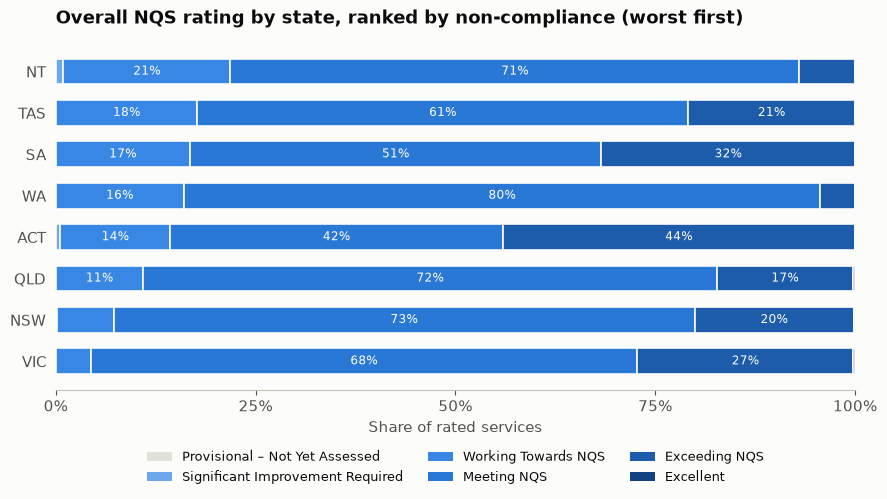

Worst: NT (21.9% non-compliant)   Best: VIC (4.4% non-compliant)


In [9]:

rated = df[df["State"].notna()].copy()
rated["OverallRating"] = rated["OverallRating"].astype(str)
props = (
    rated.groupby("State")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER, fill_value=0)
)
# Sort by non-compliance (Working Towards + Significant Improvement
# Required), worst first - consistent with the non-compliance framing
# used everywhere else in this stream.
props["_score"] = props["Working Towards NQS"] + props["Significant Improvement Required"]
props = props.sort_values("_score", ascending=False).drop(columns="_score")

fig, ax = plt.subplots(figsize=(9, 5.2))
stacked_bar(ax, props, RATING_ORDER, RATING_COLORS)
ax.set_title("Overall NQS rating by state, ranked by non-compliance (worst first)",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rating_by_state.png", dpi=200)
plt.show()

worst_state, best_state = props.index[0], props.index[-1]
summary["best_state"] = best_state
summary["worst_state"] = worst_state
summary["best_state_noncompliance_pct"] = round(float(props.loc[best_state, "Working Towards NQS"] + props.loc[best_state, "Significant Improvement Required"]) * 100, 1)
summary["worst_state_noncompliance_pct"] = round(float(props.loc[worst_state, "Working Towards NQS"] + props.loc[worst_state, "Significant Improvement Required"]) * 100, 1)
print(f"Worst: {worst_state} ({summary['worst_state_noncompliance_pct']}% non-compliant)   Best: {best_state} ({summary['best_state_noncompliance_pct']}% non-compliant)")



## 5. Chart 2 — NQS rating by primary service type


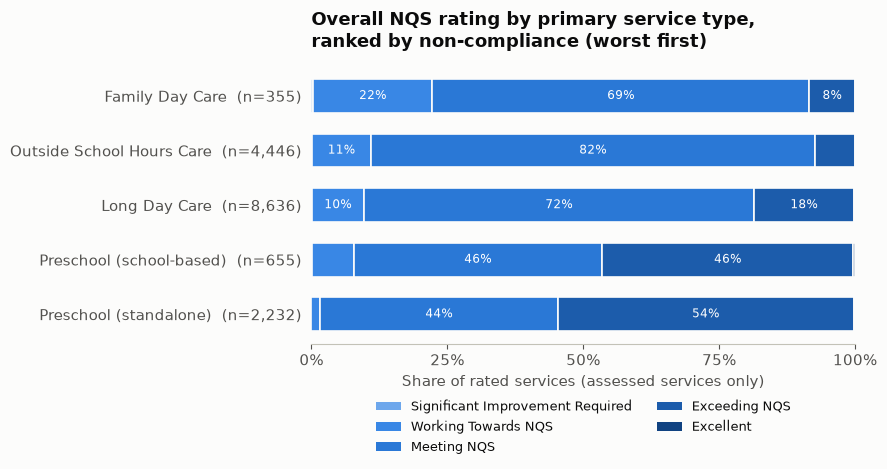

In [10]:

d2 = df[df["PrimaryServiceType"] != "Other"].copy()
d2 = d2[d2["OverallRating"].notna()]
d2["OverallRating"] = d2["OverallRating"].astype(str)
d2 = d2[d2["OverallRating"] != NOT_YET_ASSESSED]

props2 = (
    d2.groupby("PrimaryServiceType")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER_SUBSTANTIVE, fill_value=0)
)
counts2 = d2["PrimaryServiceType"].value_counts()
# Ranked by non-compliance, worst first - consistent with Chart 1 and
# Chart 3's framing (who's actually failing the legal minimum, not who's
# excelling).
props2["_score"] = props2["Working Towards NQS"] + props2["Significant Improvement Required"]
props2 = props2.sort_values("_score", ascending=False).drop(columns="_score")
props2.index = [f"{i}  (n={counts2[i]:,})" for i in props2.index]

fig, ax = plt.subplots(figsize=(9, 5.0))
stacked_bar(ax, props2, RATING_ORDER_SUBSTANTIVE, RATING_COLORS)
ax.set_title("Overall NQS rating by primary service type,\nranked by non-compliance (worst first)",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services (assessed services only)")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER_SUBSTANTIVE]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_rating_by_service_type.png", dpi=200)
plt.show()

summary["service_type_counts"] = counts2.to_dict()



## 6. Chart 3 — Which Quality Area drags each state down?

**Business question:** not "who's excelling" (Chart 1 already answered that) but "who's actually failing to meet the legal standard, and in which of the seven components?" This deliberately measures non-compliance (Working Towards NQS / Significant Improvement Required), not the share reaching Exceeding.


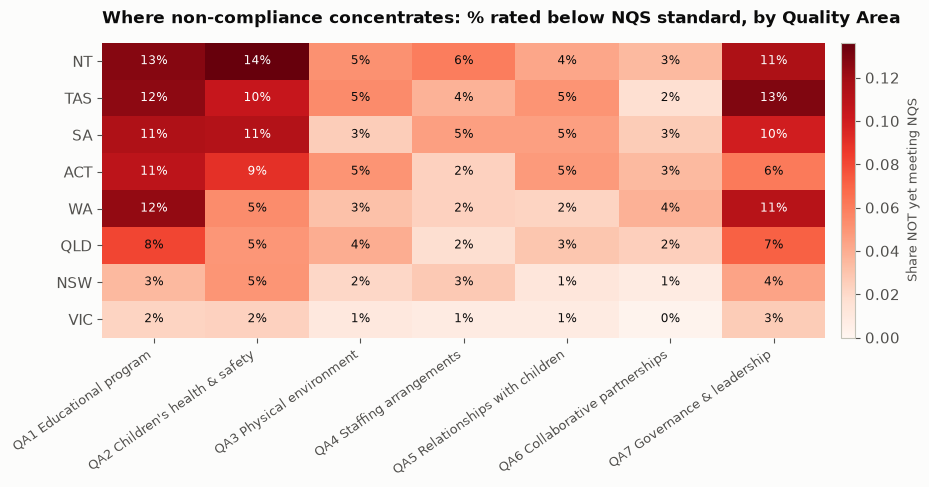

Weakest (highest non-compliance): QA1 Educational program
Strongest (lowest non-compliance): QA6 Collaborative partnerships

Mean non-compliance by state, worst first:
NT     8.1
TAS    7.4
SA     6.7
ACT    5.9
WA     5.8
QLD    4.5
NSW    2.8
VIC    1.4
dtype: float64


In [11]:

d3 = df[df["State"].notna()].copy()
qa_cols = list(QUALITY_AREA_LABELS.keys())
rows = []
for state, g in d3.groupby("State"):
    row = {}
    for col in qa_cols:
        s = g[col].astype(str)
        s = s[(s != "nan") & (s != NOT_YET_ASSESSED)]
        # Non-compliance: rated below the NQS standard - the areas actively
        # failing to meet the National Law, not just short of "Exceeding".
        row[QUALITY_AREA_LABELS[col]] = s.isin(["Working Towards NQS", "Significant Improvement Required"]).mean() if len(s) else np.nan
    rows.append(pd.Series(row, name=state))
heat = pd.DataFrame(rows)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]  # worst (highest non-compliance) first

fig, ax = plt.subplots(figsize=(9.5, 5))
im = ax.imshow(heat.values, cmap="Reds", vmin=0, vmax=heat.values.max(), aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if v > heat.values.max() * 0.6 else INK_PRIMARY)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Share NOT yet meeting NQS", color=INK_SECONDARY, fontsize=9)
ax.set_title("Where non-compliance concentrates: % rated below NQS standard, by Quality Area",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_quality_area_heatmap.png", dpi=200)
plt.show()

summary["weakest_quality_area_nationally"] = heat.mean(axis=0).idxmax()  # highest non-compliance
summary["strongest_quality_area_nationally"] = heat.mean(axis=0).idxmin()  # lowest non-compliance
print("Weakest (highest non-compliance):", summary["weakest_quality_area_nationally"])
print("Strongest (lowest non-compliance):", summary["strongest_quality_area_nationally"])
print()
print("Mean non-compliance by state, worst first:")
print((heat.mean(axis=1) * 100).round(1))



## 7. Chart 4 (spatial) — Services across Australia by rating

Basemap: simplified Australian state boundaries from [rowanhogan/australian-states](https://github.com/rowanhogan/australian-states) (public GitHub repo derived from ABS boundaries) — visual context only, not a statistical join.


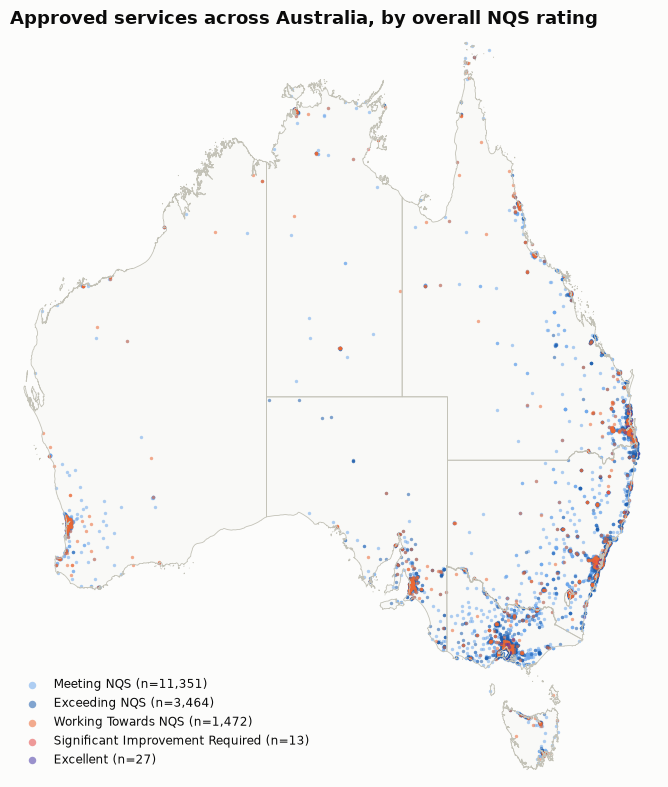

In [12]:

d4 = df[df["lon"].notna() & df["lat"].notna() & ~df["geocode_suspect"]].copy()
d4["OverallRating"] = d4["OverallRating"].astype(str)
tier_colors = {
    "Significant Improvement Required": CAT["red"], "Working Towards NQS": CAT["orange"],
    "Meeting NQS": SEQ_BLUE[2], "Exceeding NQS": SEQ_BLUE[5], "Excellent": CAT["violet"],
}
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)
for tier in ["Meeting NQS", "Exceeding NQS", "Working Towards NQS", "Significant Improvement Required", "Excellent"]:
    sub = d4[d4["OverallRating"] == tier]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=6, alpha=0.55, linewidths=0, color=tier_colors[tier], label=f"{tier} (n={len(sub):,})")
ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Approved services across Australia, by overall NQS rating", fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=10)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, markerscale=2.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_spatial_ratings_map.png", dpi=200)
plt.show()

summary["n_mapped"] = int(len(d4))
summary["n_excluded_suspect_geocode"] = int(df["geocode_suspect"].sum())



## 8. Chart 5 — Does distance from transport hurt quality?

**Business question:** does poor transport access have a NEGATIVE impact on quality — i.e. does it push services below the NQS standard, not just below "Exceeding"? Torres Strait Island / very remote services (>100km from a station — genuine, not a data error) are excluded here only, since at national scale they'd compress every other distance bin onto a single pixel.


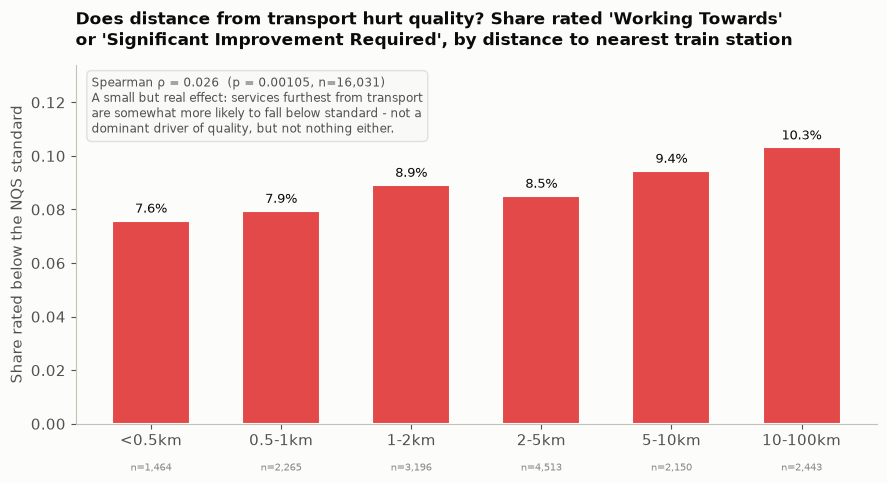

Spearman rho = 0.0259, p = 0.00105, n = 16,031


In [13]:

idx5 = rated_only(df["OverallRating"].dropna()).index
sub5 = df.loc[idx5].copy()
sub5["OverallRating"] = sub5["OverallRating"].astype(str)
# "Negative impact" = falling BELOW the NQS standard (Working Towards NQS or
# Significant Improvement Required) - a direct "at risk" measure, rather than
# the share exceeding it.
sub5["BelowStandard"] = sub5["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)
sub5_clean = sub5[~sub5["train_dist_outlier"]].copy()
n_excluded5 = int(sub5["train_dist_outlier"].sum())

bins5 = [0, 0.5, 1, 2, 5, 10, 100]
labels5 = ["<0.5km", "0.5-1km", "1-2km", "2-5km", "5-10km", "10-100km"]
sub5_clean["dist_bin"] = pd.cut(sub5_clean["DistanceToTrainStation_km"], bins=bins5, labels=labels5)
props5 = sub5_clean.groupby("dist_bin", observed=True)["BelowStandard"].mean()
counts5 = sub5_clean["dist_bin"].value_counts().reindex(labels5)

rho5, pval5 = stats.spearmanr(sub5_clean["DistanceToTrainStation_km"], sub5_clean["BelowStandard"])

ymax5 = max(props5.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels5, props5.reindex(labels5).values, color=CAT["red"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels5):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{bar.get_height():.1%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax5, f"n={counts5[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax5)
ax.set_ylabel("Share rated below the NQS standard")
ax.set_title("Does distance from transport hurt quality? Share rated 'Working Towards'\nor 'Significant Improvement Required', by distance to nearest train station",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.02, 0.97, f"Spearman ρ = {rho5:.3f}  (p = {pval5:.3g}, n={len(sub5_clean):,})\n"
                    "A small but real effect: services furthest from transport\n"
                    "are somewhat more likely to fall below standard - not a\n"
                    "dominant driver of quality, but not nothing either.",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_transport_vs_quality.png", dpi=200)
plt.show()

summary["transport_belowstandard_spearman_rho"] = round(float(rho5), 4)
summary["transport_belowstandard_spearman_p"] = float(pval5)
summary["belowstandard_pct_closest_bin"] = round(float(props5.iloc[0]) * 100, 1)
summary["belowstandard_pct_farthest_bin"] = round(float(props5.iloc[-1]) * 100, 1)
summary["n_excluded_remote_outliers"] = n_excluded5
print(f"Spearman rho = {rho5:.4f}, p = {pval5:.3g}, n = {len(sub5_clean):,}")



# Stream 2: Accessibility & Coverage

The assignment sets four specific requirements for this stream. Rather than a
loose accessibility overview, each of the four charts below answers exactly
one requirement, with a claim the chart proves rather than a neutral
description. One bridging chart sits between requirements 2 and 3, asking
whether the connectivity gap tracks how rural a state is:

1. Assess the geographical distribution of services, focusing on disparities
   between urban and rural areas → **Chart 6**: services are ~12,000x more
   concentrated per km² in major cities than in rural areas.
2. Highlight regions where additional services may be required → **Chart 7**:
   a ranked list of the specific state x area-type combinations furthest from
   an alternative service.
   - **Chart 8 (bridge)**: is a state's connectivity problem just how rural
     it is? Mostly, but not for WA — its worst coverage gap sits inside a
     state that's otherwise the best-connected in the country.
3. Use transport data to evaluate whether services are well-connected to
   public infrastructure → **Chart 9**: most services nationally are
   well-connected, which makes the collapse in small country towns stand
   out clearly.
4. Identify underserved areas based on distance to train/bus stations →
   **Chart 10**: a spatial map of every poorly-connected service.

## 9. Urban/rural classification — ABS Section of State (SOS) 2021

Per the assignment brief, Option A (spatial join) is used: each service's own lon/lat is matched against the ABS **Section of State** boundary polygons via `geopandas.sjoin`. SOS was chosen over the coarser Remoteness Areas file because its population-based categories (Major Urban / Other Urban / Bounded Locality / Rural Balance) collapse naturally into an urban/rural binary.

Source: ABS Digital Boundary Files, `SOS_2021_AUST_GDA2020` shapefile (included in this repo under `data/external/sos_2021/`).

A handful of coastal/island points fall just outside every polygon due to coastline generalisation — those get a nearest-polygon fallback rather than being left unclassified (only 1 of 17,653 services needed it).


In [14]:

URBAN_CATEGORIES = {"Major Urban", "Other Urban"}
RURAL_CATEGORIES = {"Bounded Locality", "Rural Balance"}
SOS_ORDER = ["Major Urban", "Other Urban", "Bounded Locality", "Rural Balance"]
MIN_CELL_N = 15  # cells below this are masked - too few services for a reliable rate

# A service counts as "well-connected" if it's within a short drive of
# either mode - not walking distance, which the data doesn't support as a
# national baseline (median distance to a bus stop alone is 9.3km). 5km to
# a train station and 10km to a bus stop are both roughly a 10-15 minute
# drive - a reasonable "not effectively cut off" bar, set so the majority
# of the country clears it and the minority that doesn't stands out as a
# real gap rather than an artefact of an unrealistically strict cutoff.
TRAIN_CONNECTED_KM = 5.0
BUS_CONNECTED_KM = 10.0


def classify_urban_rural(df):
    sos = gpd.read_file(SOS_SHAPEFILE)
    sos = sos[sos.geometry.notna()].copy()

    pts = gpd.GeoDataFrame(
        df[["lon", "lat"]], geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326", index=df.index,
    ).to_crs(sos.crs)

    cols = ["SOS_NAME21", "STE_NAME21", "geometry"]
    joined = gpd.sjoin(pts, sos[cols], how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]

    unmatched = joined["SOS_NAME21"].isna()
    if unmatched.any():
        albers = "EPSG:3577"
        nearest = gpd.sjoin_nearest(pts.loc[unmatched].to_crs(albers), sos[cols].to_crs(albers), how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[unmatched, "SOS_NAME21"] = nearest["SOS_NAME21"]
        joined.loc[unmatched, "STE_NAME21"] = nearest["STE_NAME21"]

    out = df.copy()
    out["SOS_Category"] = joined["SOS_NAME21"].reindex(out.index)
    out["UrbanRural"] = out["SOS_Category"].map(
        lambda c: "Urban" if c in URBAN_CATEGORIES else ("Rural" if c in RURAL_CATEGORIES else pd.NA)
    )
    return out, sos


df, sos_boundaries = classify_urban_rural(df)
sos_area_by_cat = sos_boundaries.groupby("SOS_NAME21")["AREASQKM21"].sum()
summary["urban_rural_counts"] = df["UrbanRural"].value_counts(dropna=False).to_dict()
summary["sos_category_counts"] = df["SOS_Category"].value_counts(dropna=False).to_dict()
df["SOS_Category"].value_counts(dropna=False)


SOS_Category
Major Urban         12850
Other Urban          3578
Bounded Locality      616
Rural Balance         609
Name: count, dtype: int64


## 10. Chart 6 — Requirement 1: geographical distribution, urban vs rural disparity

**Business question:** how much more concentrated is service provision in cities than in the country, once you account for the different area each category covers?


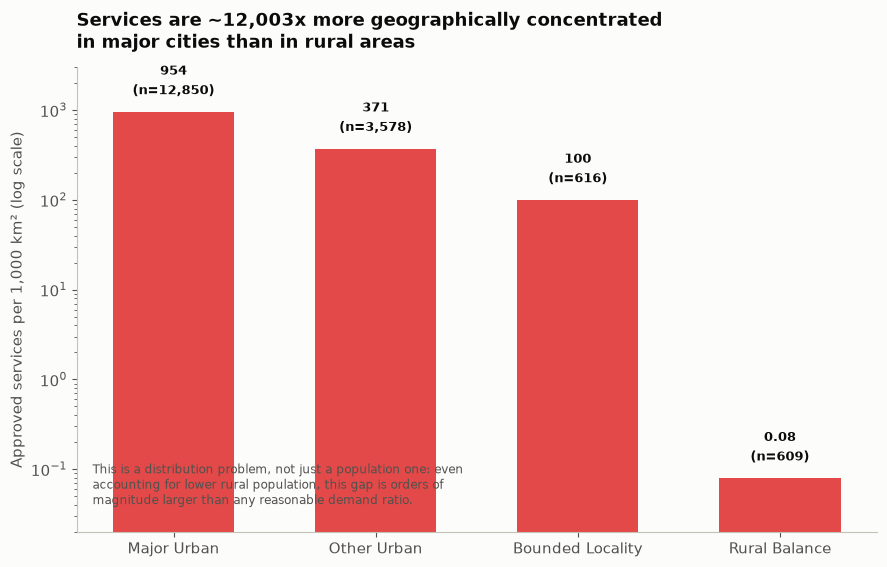

Density ratio (Major Urban : Rural Balance) = 12,003x


In [15]:

counts6 = df["SOS_Category"].value_counts()
density6 = (counts6 / sos_area_by_cat.reindex(counts6.index)) * 1000
density6 = density6.reindex(SOS_ORDER)

fig, ax = plt.subplots(figsize=(9, 5.8))
bars = ax.bar(SOS_ORDER, density6.values, color=CAT["red"], width=0.6)
ax.set_yscale("log")
ax.set_ylim(0.02, 3000)  # fixed range so every bar/label sits inside the axes
for bar, cat in zip(bars, SOS_ORDER):
    v = density6[cat]
    label = f"{v:,.0f}" if v >= 1 else f"{v:.2f}"
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.35, f"{label}\n(n={counts6[cat]:,})",
            ha="center", va="bottom", fontsize=9, fontweight="bold", linespacing=1.6)
ax.set_ylabel("Approved services per 1,000 km² (log scale)")
ratio6 = density6["Major Urban"] / density6["Rural Balance"]
ax.set_title(f"Services are ~{ratio6:,.0f}x more geographically concentrated\nin major cities than in rural areas",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.02, 0.06, "This is a distribution problem, not just a population one: even\n"
                    "accounting for lower rural population, this gap is orders of\n"
                    "magnitude larger than any reasonable demand ratio.",
        transform=ax.transAxes, ha="left", fontsize=8.5, color=INK_SECONDARY)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_geographic_distribution.png", dpi=200)
plt.show()

summary["density_major_urban_per_1000km2"] = round(float(density6["Major Urban"]), 1)
summary["density_rural_balance_per_1000km2"] = round(float(density6["Rural Balance"]), 3)
summary["density_ratio_urban_to_rural"] = round(float(ratio6), 0)
print(f"Density ratio (Major Urban : Rural Balance) = {ratio6:,.0f}x")



## 11. Chart 7 — Requirement 2: highlight regions where additional services may be required

**Business question:** for each state and area-type combination, how far away is a family's realistic backup option if their usual service is full or closed? Coverage is measured as the median distance from each service to its nearest *other* service — a direct "is there a fallback nearby" test, not a land-area density figure dominated by uninhabited land.


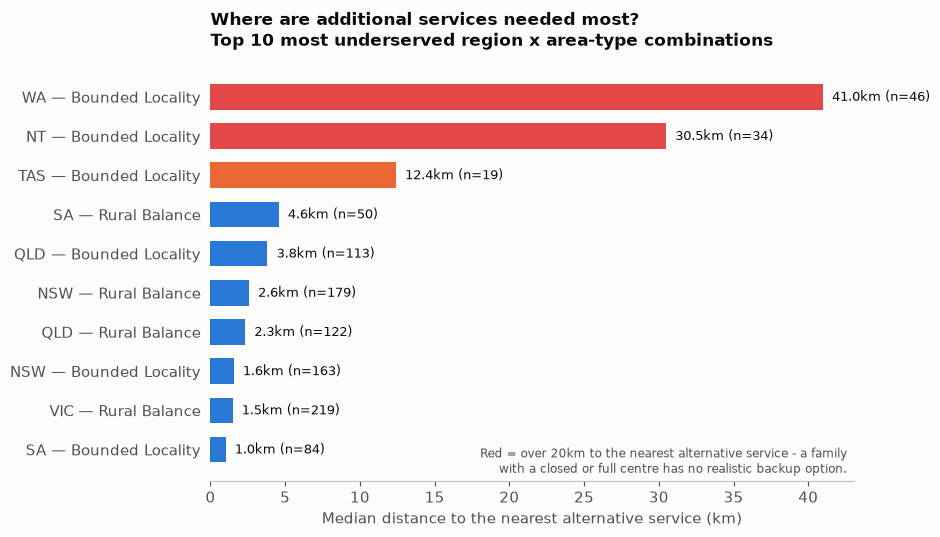

Most underserved: WA / Bounded Locality — median 41.0km to the nearest alternative service


In [16]:

pts7 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326").to_crs("EPSG:3577")
coords7 = np.vstack([pts7.geometry.x, pts7.geometry.y]).T
dist7, _ = cKDTree(coords7).query(coords7, k=2)  # k=1 is the point itself
df["nearest_service_km"] = dist7[:, 1] / 1000

d7 = df[df["State"].notna() & df["SOS_Category"].notna()]
cell7 = d7.groupby(["State", "SOS_Category"]).agg(
    median_km=("nearest_service_km", "median"), n=("nearest_service_km", "size")
).reset_index()
cell7 = cell7[cell7["n"] >= MIN_CELL_N].sort_values("median_km", ascending=False).head(10)
cell7["label"] = cell7["State"] + " — " + cell7["SOS_Category"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors7 = [CAT["red"] if v > 20 else (CAT["orange"] if v > 5 else CAT["blue"]) for v in cell7["median_km"]]
bars = ax.barh(cell7["label"], cell7["median_km"], color=colors7, height=0.65)
ax.invert_yaxis()
for bar, km, n in zip(bars, cell7["median_km"], cell7["n"]):
    ax.text(bar.get_width() + max(cell7["median_km"]) * 0.015, bar.get_y() + bar.get_height() / 2,
            f"{km:.1f}km (n={n:,})", va="center", fontsize=9)
ax.set_xlabel("Median distance to the nearest alternative service (km)")
ax.set_title("Where are additional services needed most?\nTop 10 most underserved region x area-type combinations",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.99, 0.02, "Red = over 20km to the nearest alternative service - a family\n"
                    "with a closed or full centre has no realistic backup option.",
        transform=ax.transAxes, ha="right", fontsize=8.5, color=INK_SECONDARY)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_underserved_regions.png", dpi=200)
plt.show()

top7 = cell7.iloc[0]
summary["most_underserved_state_sos"] = f"{top7['State']} / {top7['SOS_Category']}"
summary["most_underserved_median_km"] = round(float(top7["median_km"]), 1)
summary["n_regions_over_20km_to_next_service"] = int((cell7["median_km"] > 20).sum())
print(f"Most underserved: {summary['most_underserved_state_sos']} — median {summary['most_underserved_median_km']}km to the nearest alternative service")



## 12. Chart 8 (bridge) — Is a state's connectivity problem just how rural it is?

**Business question:** Chart 1 flagged the Northern Territory and Tasmania as the worst compliance states, and Chart 7 flagged WA's Bounded Localities as the single biggest coverage gap in the country. Before treating "worst state" as one consistent list, does a state's transport-connectivity problem simply track how much of it is rural — or are some states' problems concentrated in a small pocket rather than spread statewide?


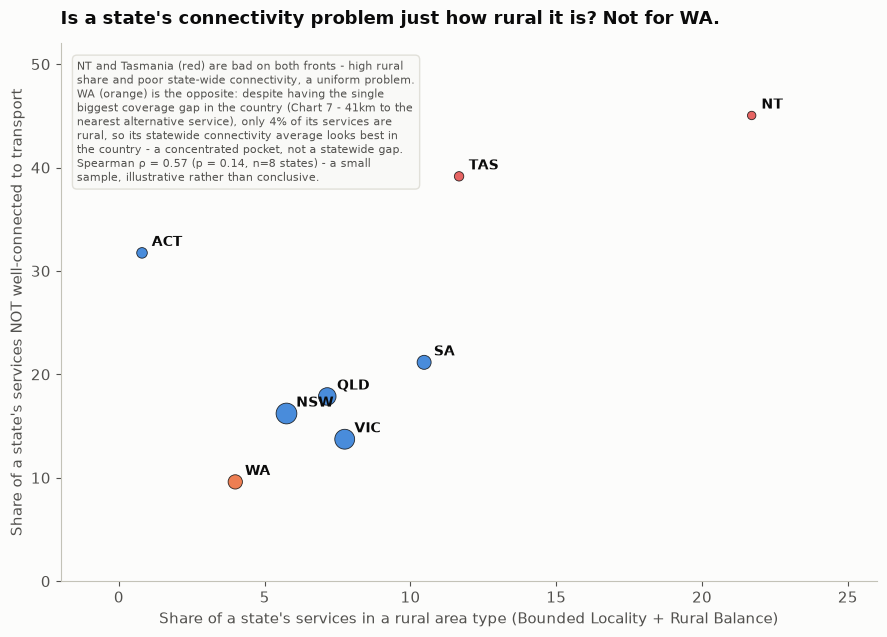

In [17]:

d8b = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d8b["WellConnected"] = (d8b["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d8b["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d8b = d8b[d8b["State"].notna()]
poorly_connected8b = d8b.groupby("State")["WellConnected"].apply(lambda s: (~s).mean() * 100)
rural_share8b = df[df["State"].notna()].groupby("State")["SOS_Category"].apply(
    lambda s: s.isin(["Bounded Locality", "Rural Balance"]).mean() * 100
)
counts8b = d8b["State"].value_counts()
states8b = list(poorly_connected8b.index)
rural_share8b = rural_share8b.reindex(states8b)

rho8b, pval8b = stats.spearmanr(rural_share8b, poorly_connected8b)

fig, ax = plt.subplots(figsize=(9, 6.5))
sizes8b = (counts8b.reindex(states8b) ** 0.5) * 3
colors8b = [CAT["red"] if s in ("NT", "TAS") else (CAT["orange"] if s == "WA" else CAT["blue"]) for s in states8b]
ax.scatter(rural_share8b, poorly_connected8b, s=sizes8b, color=colors8b, alpha=0.85,
           edgecolors=INK_PRIMARY, linewidths=0.6, zorder=3)
for s in states8b:
    ax.annotate(s, (rural_share8b[s], poorly_connected8b[s]), xytext=(7, 5), textcoords="offset points",
                fontsize=10, fontweight="bold", color=INK_PRIMARY)
ax.set_xlim(-2, 26)
ax.set_ylim(0, 52)
ax.set_xlabel("Share of a state's services in a rural area type (Bounded Locality + Rural Balance)")
ax.set_ylabel("Share of a state's services NOT well-connected to transport")
ax.set_title("Is a state's connectivity problem just how rural it is? Not for WA.",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.02, 0.97,
        "NT and Tasmania (red) are bad on both fronts - high rural\n"
        "share and poor state-wide connectivity, a uniform problem.\n"
        "WA (orange) is the opposite: despite having the single\n"
        "biggest coverage gap in the country (Chart 7 - 41km to the\n"
        "nearest alternative service), only 4% of its services are\n"
        "rural, so its statewide connectivity average looks best in\n"
        "the country - a concentrated pocket, not a statewide gap.\n"
        f"Spearman ρ = {rho8b:.2f} (p = {pval8b:.2g}, n=8 states) - a small\n"
        "sample, illustrative rather than conclusive.",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_state_connectivity_vs_rurality.png", dpi=200)
plt.show()

summary["state_rural_share_pct"] = {s: round(float(rural_share8b[s]), 1) for s in states8b}
summary["state_poorly_connected_pct"] = {s: round(float(poorly_connected8b[s]), 1) for s in states8b}
summary["state_rurality_connectivity_spearman_rho"] = round(float(rho8b), 4)
summary["state_rurality_connectivity_spearman_p"] = float(pval8b)



## 13. Chart 9 — Requirement 3: are services well-connected to public transport?

**Business question:** using the actual transport-distance fields in the data, what share of services fail a reasonable "well-connected" test — within 5km of a train station or 10km of a bus stop, a generous drivable bar chosen so the national majority clears it — and does the minority that fails track the urban/rural split?


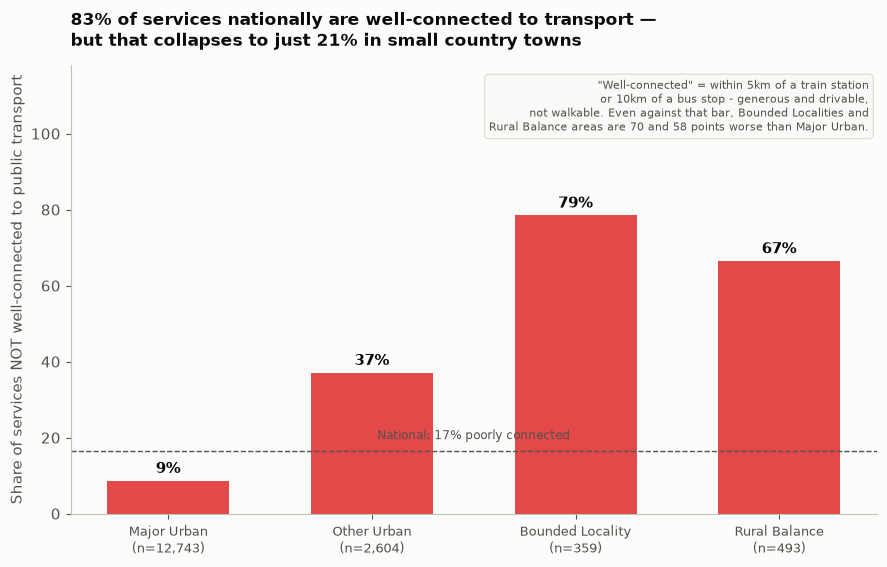

National: 16.6% poorly connected. By area: {'Major Urban': np.float64(8.7), 'Other Urban': np.float64(37.1), 'Bounded Locality': np.float64(78.6), 'Rural Balance': np.float64(66.5)}


In [18]:

d8 = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d8["WellConnected"] = (d8["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d8["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d8 = d8[d8["SOS_Category"].notna()]
poorly_connected8 = d8.groupby("SOS_Category")["WellConnected"].apply(lambda s: (~s).mean() * 100).reindex(SOS_ORDER)
counts8 = d8["SOS_Category"].value_counts().reindex(SOS_ORDER)
national_poor8 = (~d8["WellConnected"]).mean() * 100

fig, ax = plt.subplots(figsize=(9, 5.8))
bars = ax.bar(SOS_ORDER, poorly_connected8.values, color=CAT["red"], width=0.6)
for bar, cat in zip(bars, SOS_ORDER):
    v = poorly_connected8[cat]
    ax.text(bar.get_x() + bar.get_width() / 2, v + 2, f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(len(SOS_ORDER)))
ax.set_xticklabels([f"{cat}\n(n={counts8[cat]:,})" for cat in SOS_ORDER], fontsize=9.5)
ax.axhline(national_poor8, color=INK_SECONDARY, linestyle="--", linewidth=1)
ax.text(1.5, national_poor8 + 3, f"National: {national_poor8:.0f}% poorly connected",
        ha="center", fontsize=8.5, color=INK_SECONDARY)
ax.set_ylim(0, 118)
ax.set_ylabel("Share of services NOT well-connected to public transport")
gap8 = poorly_connected8["Bounded Locality"] - poorly_connected8["Major Urban"]
ax.set_title(f"{100 - national_poor8:.0f}% of services nationally are well-connected to transport —\n"
             f"but that collapses to just {100 - poorly_connected8['Bounded Locality']:.0f}% in small country towns",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.99, 0.97, f"\"Well-connected\" = within {TRAIN_CONNECTED_KM:.0f}km of a train station\n"
                    f"or {BUS_CONNECTED_KM:.0f}km of a bus stop - generous and drivable,\n"
                    "not walkable. Even against that bar, Bounded Localities and\n"
                    f"Rural Balance areas are {gap8:.0f} and "
                    f"{poorly_connected8['Rural Balance'] - poorly_connected8['Major Urban']:.0f} points worse than "
                    "Major Urban.",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_transport_connectivity.png", dpi=200)
plt.show()

summary["national_poorly_connected_pct"] = round(float(national_poor8), 1)
for cat in SOS_ORDER:
    summary[f"poorly_connected_{cat.lower().replace(' ', '_')}_pct"] = round(float(poorly_connected8[cat]), 1)
print(f"National: {national_poor8:.1f}% poorly connected. By area: {dict(poorly_connected8.round(1))}")



## 14. Chart 10 — Requirement 4: identify underserved areas based on distance to train/bus stations

**Business question:** where do the transport-underserved services concentrate spatially? Requirement 3 established the scale of the problem nationally and by area type; this maps every individual service so the concentration is visible directly, not just as a state-level or area-type average.


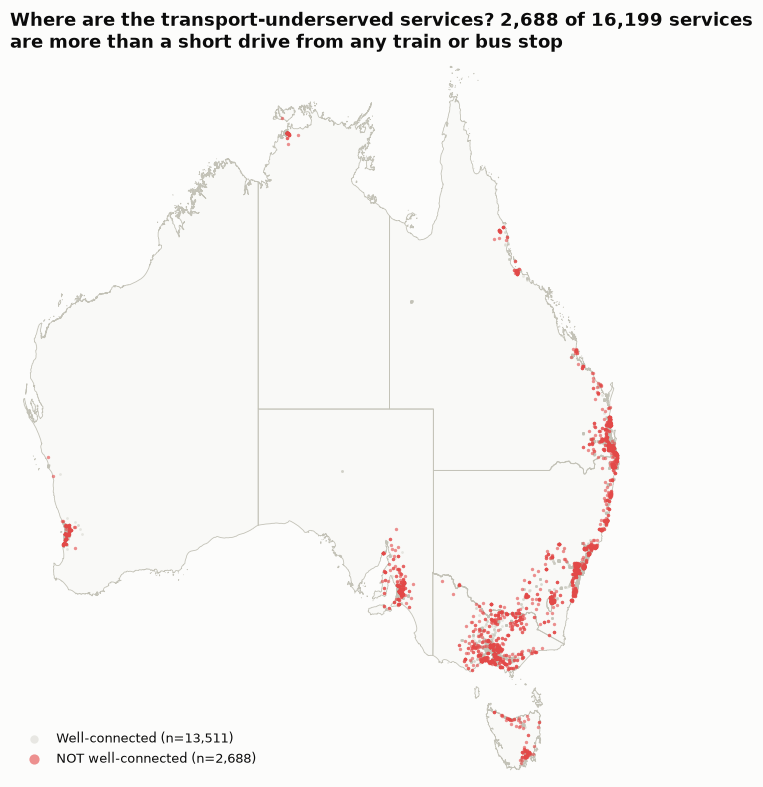

In [19]:

d9 = df[~df["train_dist_outlier"] & ~df["bus_dist_outlier"]].copy()
d9["WellConnected"] = (d9["DistanceToTrainStation_km"] <= TRAIN_CONNECTED_KM) | (d9["DistanceToBusStation_km"] <= BUS_CONNECTED_KM)
d9 = d9[d9["lon"].notna() & d9["lat"].notna() & ~d9["geocode_suspect"]]
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)

connected9 = d9[d9["WellConnected"]]
poor9 = d9[~d9["WellConnected"]]
ax.scatter(connected9["lon"], connected9["lat"], s=4, alpha=0.35, linewidths=0,
           color=BASELINE, label=f"Well-connected (n={len(connected9):,})", zorder=2)
ax.scatter(poor9["lon"], poor9["lat"], s=6, alpha=0.6, linewidths=0,
           color=CAT["red"], label=f"NOT well-connected (n={len(poor9):,})", zorder=3)

ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"Where are the transport-underserved services? {len(poor9):,} of {len(d9):,} services\n"
             "are more than a short drive from any train or bus stop",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=10)
ax.legend(loc="lower left", frameon=False, fontsize=9, markerscale=3)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_spatial_connectivity.png", dpi=200)
plt.show()

summary["n_poorly_connected"] = int(len(poor9))
summary["n_well_connected"] = int(len(connected9))



# Stream 3: Operational Trends

## 15. Capacity, operating hours & approval dates

Setting up two operational fields: capacity is already in the data (`NumberOfApprovedPlaces`); opening hours need to be derived from the per-weekday start/end time columns. Services record hours under three separate schedules — "Annual" (year-round), "School Terms Only" (two sessions), and "Holiday Care" — so which one a service has filled in is itself informative about how it operates.


In [20]:

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

has_annual = df["Annual Monday Start Time"].notna()
has_term = df["School Terms Only Session 1 Monday Start Time"].notna()
df["OperatingPattern"] = "Neither / other pattern"
df.loc[~has_annual & has_term, "OperatingPattern"] = "Term-time only"
df.loc[has_annual, "OperatingPattern"] = "Year-round"


def to_hours(series):
    return pd.to_timedelta(series.astype(str), errors="coerce").dt.total_seconds() / 3600


total_hours = pd.Series(0.0, index=df.index)
for day in DAYS:
    start = to_hours(df[f"Annual {day} Start Time"])
    end = to_hours(df[f"Annual {day} End Time"])
    total_hours = total_hours.add((end - start).clip(lower=0).fillna(0))
df["WeeklyHours"] = np.where(has_annual, total_hours, np.nan)

# Family Day Care schemes record round-the-clock availability across their
# whole educator network (median ~168h/week = "always open"), which isn't
# a comparable "opening hours" figure to a single centre's - excluded from
# the hours analysis, kept for the capacity/type charts.
df.loc[df["PrimaryServiceType"] == "Family Day Care", "WeeklyHours"] = np.nan

print(df["OperatingPattern"].value_counts())
print()
print(df["WeeklyHours"].describe())


OperatingPattern
Year-round                 10633
Term-time only              6093
Neither / other pattern      927
Name: count, dtype: int64

count    10267.000000
mean        53.731492
std          9.976385
min          0.000000
25%         52.500000
50%         55.000000
75%         60.000000
max        167.883333
Name: WeeklyHours, dtype: float64



## 16. Chart 11 — Does service size predict whether it meets the standard?

**Business question:** does a bigger centre have more resources to reliably meet the standard, or does a bigger operation just have more that can go wrong? Tested directly, in quintile bins of actual capacity, against non-compliance (Working Towards NQS or Significant Improvement Required) - not against "Exceeding", which is a different, higher bar than the compliance question this stream is about.


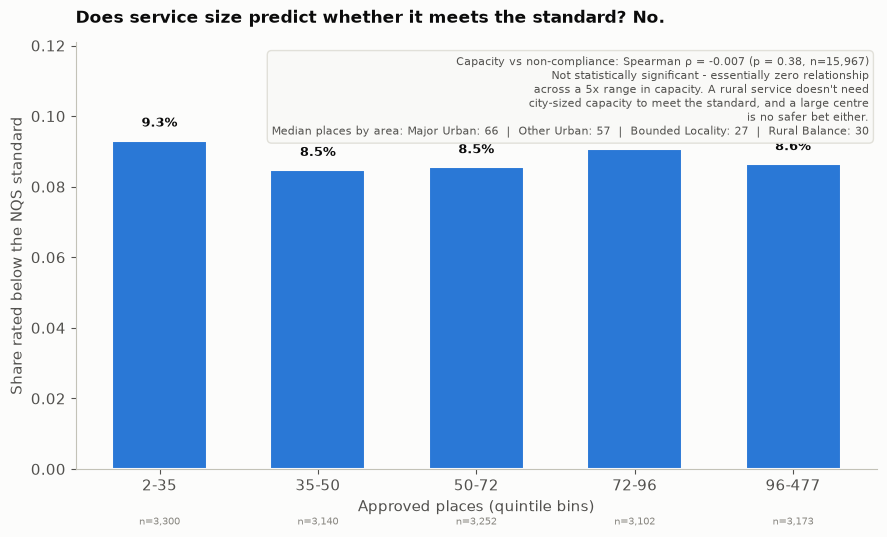

In [21]:

# Family Day Care excluded: capacity is recorded per individually-registered
# educator across a scheme, not as a single site limit, so NumberOfApprovedPlaces
# is populated for only 2 of 417 FDC services - not enough for a meaningful median.
d10 = df[~df["PrimaryServiceType"].isin(["Other", "Family Day Care"])].copy()
d10 = d10.dropna(subset=["NumberOfApprovedPlaces"])
d10 = d10[d10["OverallRating"].notna()]
d10["OverallRating"] = d10["OverallRating"].astype(str)
d10 = d10[d10["OverallRating"] != NOT_YET_ASSESSED]
d10["BelowStandard"] = d10["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)
sos_places = df.groupby("SOS_Category")["NumberOfApprovedPlaces"].median()

# Quantile bins (not fixed cutoffs) so each bin has enough services for a
# reliable rate and the labels show the real capacity range.
d10["cap_bin"], edges10 = pd.qcut(d10["NumberOfApprovedPlaces"], q=5, retbins=True, duplicates="drop")
labels10 = [f"{int(edges10[i])}-{int(edges10[i + 1])}" for i in range(len(edges10) - 1)]
d10["cap_bin"] = pd.qcut(d10["NumberOfApprovedPlaces"], q=5, labels=labels10, duplicates="drop")
props10 = d10.groupby("cap_bin", observed=True)["BelowStandard"].mean()
counts10 = d10["cap_bin"].value_counts().reindex(labels10)

rho10, pval10 = stats.spearmanr(d10["NumberOfApprovedPlaces"], d10["BelowStandard"])

ymax10 = max(props10.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels10, props10.reindex(labels10).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels10):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004, f"{bar.get_height():.1%}",
            ha="center", fontsize=9, color=INK_PRIMARY, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax10, f"n={counts10[lbl]:,}",
            ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax10)
ax.set_xlabel("Approved places (quintile bins)")
ax.set_ylabel("Share rated below the NQS standard")
ax.set_title("Does service size predict whether it meets the standard? No.",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
sos_line10 = "  |  ".join(f"{cat}: {sos_places[cat]:.0f}" for cat in SOS_ORDER)
ax.text(0.99, 0.97,
        f"Capacity vs non-compliance: Spearman ρ = {rho10:.3f} (p = {pval10:.2g}, n={len(d10):,})\n"
        "Not statistically significant - essentially zero relationship\n"
        "across a 5x range in capacity. A rural service doesn't need\n"
        "city-sized capacity to meet the standard, and a large centre\n"
        "is no safer bet either.\n"
        f"Median places by area: {sos_line10}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_capacity_by_type.png", dpi=200)
plt.show()

for cat in SOS_ORDER:
    summary[f"median_places_{cat.lower().replace(' ', '_')}"] = round(float(sos_places[cat]), 1)
summary["capacity_noncompliance_spearman_rho"] = round(float(rho10), 4)
summary["capacity_noncompliance_spearman_p"] = float(pval10)
summary["noncompliance_pct_smallest_capacity_bin"] = round(float(props10.iloc[0]) * 100, 1)
summary["noncompliance_pct_largest_capacity_bin"] = round(float(props10.iloc[-1]) * 100, 1)



## 17. Chart 12 — Services approved per year, and the compliance signal underneath it

**Data quality note:** 2012 shows an enormous spike. That's not organic growth — the National Quality Framework commenced in January 2012, and every already-operating service was bulk-transferred onto new approval numbers under the new system that year. The right-hand panel is the real payoff: does WHEN a service was approved relate to whether it meets the standard today?


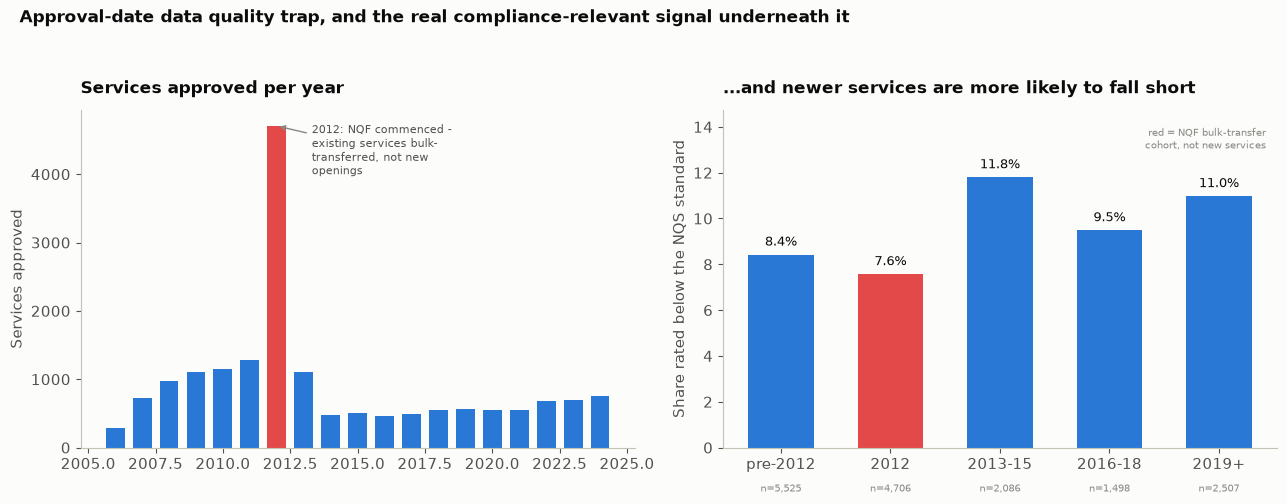

In [22]:

d12 = df[df["ApprovalYear"].between(2006, 2024)]
by_year = d12.groupby("ApprovalYear").size()

rated12 = d12[d12["OverallRating"].notna()].copy()
rated12["OverallRating"] = rated12["OverallRating"].astype(str)
rated12 = rated12[rated12["OverallRating"] != NOT_YET_ASSESSED]
bins12 = [2005, 2012, 2013, 2016, 2019, 2025]
labels12 = ["pre-2012", "2012", "2013-15", "2016-18", "2019+"]
rated12["cohort"] = pd.cut(rated12["ApprovalYear"], bins=bins12, labels=labels12, right=False)
cohort_noncompliance = rated12.groupby("cohort", observed=True)["OverallRating"].apply(lambda s: s.isin(["Working Towards NQS", "Significant Improvement Required"]).mean())
cohort_counts = rated12["cohort"].value_counts().reindex(labels12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))

colors12 = [CAT["red"] if y == 2012 else CAT["blue"] for y in by_year.index]
ax1.bar(by_year.index, by_year.values, color=colors12, width=0.7)
ax1.annotate(
    "2012: NQF commenced -\nexisting services bulk-\ntransferred, not new\nopenings",
    xy=(2012, by_year.loc[2012]), xytext=(2013.3, by_year.loc[2012] * 0.85),
    fontsize=8, color=INK_SECONDARY, arrowprops=dict(arrowstyle="->", color=INK_MUTED),
)
ax1.set_ylabel("Services approved")
ax1.set_title("Services approved per year", fontsize=12, fontweight="bold", color=INK_PRIMARY, loc="left", pad=12)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
ax1.spines["left"].set_color(BASELINE); ax1.spines["bottom"].set_color(BASELINE)

bar_colors12 = [CAT["red"] if lbl == "2012" else CAT["blue"] for lbl in labels12]
ymax12 = max(cohort_noncompliance.max() * 100 * 1.25, 5)
bars2 = ax2.bar(labels12, (cohort_noncompliance.reindex(labels12) * 100).values, color=bar_colors12, width=0.6)
for bar, lbl in zip(bars2, labels12):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.4, f"{h:.1f}%", ha="center", fontsize=9)
    ax2.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax12, f"n={cohort_counts[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax2.set_ylim(0, ymax12)
ax2.set_ylabel("Share rated below the NQS standard")
ax2.set_title("...and newer services are more likely to fall short", fontsize=12, fontweight="bold", color=INK_PRIMARY, loc="left", pad=12)
ax2.text(0.98, 0.95, "red = NQF bulk-transfer\ncohort, not new services", transform=ax2.transAxes, ha="right", va="top", fontsize=7.5, color=INK_MUTED)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
ax2.spines["left"].set_color(BASELINE); ax2.spines["bottom"].set_color(BASELINE)

fig.suptitle("Approval-date data quality trap, and the real compliance-relevant signal underneath it",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "12_approval_trend.png", dpi=200)
plt.show()

summary["approvals_2012_nqf_spike"] = int(by_year.loc[2012])
summary["approvals_2014"] = int(by_year.loc[2014])
summary["approvals_2024"] = int(by_year.loc[2024])
summary["noncompliance_pct_pre2012_cohort"] = round(float(cohort_noncompliance["pre-2012"]) * 100, 1)
summary["noncompliance_pct_2019plus_cohort"] = round(float(cohort_noncompliance["2019+"]) * 100, 1)



## 18. Chart 13 — Do longer opening hours predict non-compliance, and does transport?

Two questions in one chart: does a longer working week push a service below the NQS standard, and — following up on Chart 5's finding that distance from transport has a small but real negative effect on compliance — does transport accessibility move capacity or opening hours at all?


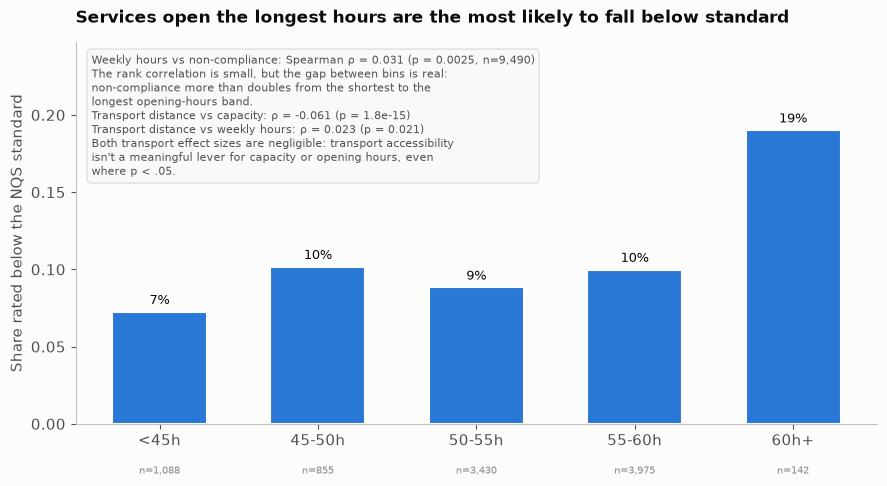

In [23]:

d13 = df[df["OverallRating"].notna() & df["WeeklyHours"].notna()].copy()
d13["OverallRating"] = d13["OverallRating"].astype(str)
d13 = d13[d13["OverallRating"] != NOT_YET_ASSESSED]
d13 = d13[d13["WeeklyHours"].between(1, 100)]
d13["BelowStandard"] = d13["OverallRating"].isin(["Working Towards NQS", "Significant Improvement Required"]).astype(int)

bins13 = [0, 45, 50, 55, 60, 100]
labels13 = ["<45h", "45-50h", "50-55h", "55-60h", "60h+"]
d13["hours_bin"] = pd.cut(d13["WeeklyHours"], bins=bins13, labels=labels13)
props13 = d13.groupby("hours_bin", observed=True)["BelowStandard"].mean()
counts13 = d13["hours_bin"].value_counts().reindex(labels13)

rho_hours, p_hours = stats.spearmanr(d13["WeeklyHours"], d13["BelowStandard"])

cap13 = df.dropna(subset=["NumberOfApprovedPlaces"])
cap13 = cap13[~cap13["train_dist_outlier"]]
rho_cap, p_cap = stats.spearmanr(cap13["DistanceToTrainStation_km"], cap13["NumberOfApprovedPlaces"])

hrs13 = df.dropna(subset=["WeeklyHours"])
hrs13 = hrs13[~hrs13["train_dist_outlier"] & hrs13["WeeklyHours"].between(1, 100)]
rho_transport_hours, p_transport_hours = stats.spearmanr(hrs13["DistanceToTrainStation_km"], hrs13["WeeklyHours"])

ymax13 = max(props13.max() * 1.3, 0.05)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels13, props13.reindex(labels13).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels13):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.0%}", ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.13 * ymax13, f"n={counts13[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, ymax13)
ax.set_ylabel("Share rated below the NQS standard")
ax.set_title("Services open the longest hours are the most likely to fall below standard", fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.02, 0.97,
        f"Weekly hours vs non-compliance: Spearman ρ = {rho_hours:.3f} (p = {p_hours:.2g}, n={len(d13):,})\n"
        "The rank correlation is small, but the gap between bins is real:\n"
        "non-compliance more than doubles from the shortest to the\n"
        "longest opening-hours band.\n"
        f"Transport distance vs capacity: ρ = {rho_cap:.3f} (p = {p_cap:.2g})\n"
        f"Transport distance vs weekly hours: ρ = {rho_transport_hours:.3f} (p = {p_transport_hours:.2g})\n"
        "Both transport effect sizes are negligible: transport accessibility\n"
        "isn't a meaningful lever for capacity or opening hours, even\n"
        "where p < .05.",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_hours_vs_quality.png", dpi=200)
plt.show()

summary["hours_noncompliance_spearman_rho"] = round(float(rho_hours), 4)
summary["hours_noncompliance_spearman_p"] = float(p_hours)
summary["noncompliance_pct_shortest_hours_bin"] = round(float(props13.iloc[0]) * 100, 1)
summary["noncompliance_pct_longest_hours_bin"] = round(float(props13.iloc[-1]) * 100, 1)
summary["transport_capacity_spearman_rho"] = round(float(rho_cap), 4)
summary["transport_hours_spearman_rho"] = round(float(rho_transport_hours), 4)
summary["transport_hours_spearman_p"] = float(p_transport_hours)



## 19. Summary for the presentation

**Service Quality**
- **State spread is large, and it's a compliance gap, not just an excellence gap**: ranked by non-compliance, the Northern Territory is worst (21.9% of services rated Working Towards NQS or Significant Improvement Required), Victoria best (4.4%) — a ~5x gap between regulatory jurisdictions applying the same National Law.
- **Overall-rating non-compliance and component-level non-compliance don't rank states identically**: Chart 3 averages non-compliance across the seven Quality Area sub-ratings rather than the single overall rating, and by that finer-grained measure WA and SA join NT and Tasmania near the top of the list even though WA ranks only 4th on the overall-rating measure — a service's overall rating isn't a simple average of its component scores. **QA1 (Educational program)** is the weakest Quality Area nationally by non-compliance; **QA6 (Collaborative partnerships)** the strongest.
- **Distance from transport has a small but real negative effect on quality**: services furthest from a train station are somewhat more likely to fall below the NQS standard (10.3% vs 7.6% for the closest, Spearman ρ ≈ 0.026) — a modest risk factor, not a dominant one.

**Accessibility & Coverage — four requirements, four proofs**
- **Geographical distribution (Chart 6)**: services are ~12,000x more concentrated per km² in Major Urban areas (954 per 1,000km²) than in Rural Balance areas (0.08 per 1,000km²) — orders of magnitude beyond any reasonable population-driven demand ratio.
- **Where additional services are needed most (Chart 7)**: WA's Bounded Localities have the worst coverage gap nationally — a median 41.0km to the nearest alternative service — followed by NT's Bounded Localities at 30.5km. Two region×area-type combinations sit above the 20km threshold where a family has no realistic backup option.
- **Is a state's connectivity problem just how rural it is? (Chart 8, bridge)**: mostly, but not for WA. NT and Tasmania are bad on both fronts — high rural share and poor statewide connectivity (a uniform problem). WA is the opposite: despite having the single biggest coverage gap in the country (Chart 7), only 4% of its services are rural, so its statewide connectivity average looks *best* in the country — the problem is a concentrated pocket, not a statewide gap (Spearman ρ ≈ 0.57, p = 0.14, n=8 states — illustrative given the small sample).
- **Transport connectivity (Chart 9)**: 83% of services nationally are well-connected to public transport (within a generous, drivable 5km of a train station or 10km of a bus stop) — but that collapses to just 21% in Bounded Localities and 34% in Rural Balance areas, against 91% in Major Urban. Setting the bar low enough that most of the country clears it is what makes this rural gap (70 points against Major Urban) stand out as real, not an artefact of an unrealistically strict national cutoff.
- **Spatially identifying underserved areas (Chart 10)**: mapping all 2,688 poorly-connected services (against 13,511 well-connected) shows the gap concentrated in small towns and rural stretches away from the main rail corridors, consistent with Chart 9's area-type breakdown.

**Operational Trends — do these factors actually predict whether a service meets the standard?**
- **Capacity does NOT predict non-compliance** (Spearman ρ ≈ -0.01, not statistically significant, p = 0.38) — the smallest-capacity quintile is 9.3% non-compliant, the largest 8.6%, essentially flat, despite capacity itself declining sharply from Major Urban (66 places median) to Bounded Locality (27).
- **Approval cohort is the strongest operational signal found**: services approved 2019 or later are **11.0% non-compliant**, against **8.4%** for pre-2012 established services — newer services haven't had time to embed practice yet. (2012 itself is excluded from this reading — it's the National Quality Framework's bulk-transfer cohort, not new services, which is why raw approval counts spike there without a matching compliance signal.)
- **Longer opening hours are a real, visible compliance risk**: non-compliance more than doubles from 7.3% for the shortest-hours band to 19.0% for the longest (60h+) — the largest operational-factor effect found, even though the Spearman rank correlation itself is small (ρ ≈ 0.03). **Transport accessibility does not meaningfully move either capacity or opening hours** (both effect sizes negligible, even where technically significant) — so while Chart 5 shows transport has a small negative effect on compliance directly, that effect isn't operating *through* capacity or hours; it's a standalone, modest risk factor.
- **Bottom line for Problem 3**: of three operational factors tested directly against non-compliance, two show a real, actionable signal (opening hours, and especially service age/approval cohort) and one doesn't (capacity) — a genuine answer tied to whether services meet the legal standard, not just a description of the operational landscape.

**Data quality**
- 10 rows were dropped as unrecoverable geocoding failures (no address data at all); everything else was checked and kept.
- Family Day Care schemes were excluded from the opening-hours analysis: they record round-the-clock availability across their educator network, not comparable to a single centre's hours.


In [24]:

Path("outputs").mkdir(exist_ok=True)
Path("outputs/summary_stats.json").write_text(json.dumps(summary, indent=2, default=str))
summary


{'n_services_total': 17653,
 'best_state': 'VIC',
 'worst_state': 'NT',
 'best_state_noncompliance_pct': 4.4,
 'worst_state_noncompliance_pct': 21.9,
 'service_type_counts': {'Long Day Care': 8636,
  'Outside School Hours Care': 4446,
  'Preschool (standalone)': 2232,
  'Preschool (school-based)': 655,
  'Family Day Care': 355},
 'weakest_quality_area_nationally': 'QA1 Educational program',
 'strongest_quality_area_nationally': 'QA6 Collaborative partnerships',
 'n_mapped': 17653,
 'n_excluded_suspect_geocode': 0,
 'transport_belowstandard_spearman_rho': 0.0259,
 'transport_belowstandard_spearman_p': 0.0010535622964976603,
 'belowstandard_pct_closest_bin': 7.6,
 'belowstandard_pct_farthest_bin': 10.3,
 'n_excluded_remote_outliers': 296,
 'urban_rural_counts': {'Urban': 16428, 'Rural': 1225},
 'sos_category_counts': {'Major Urban': 12850,
  'Other Urban': 3578,
  'Bounded Locality': 616,
  'Rural Balance': 609},
 'density_major_urban_per_1000km2': 954.4,
 'density_rural_balance_per_1000